# Dataset Feature Exploration

This notebook explores the characteristics of all synthetic datasets to understand:
1. Feature distributions
2. Pairwise correlations and scatter plots
3. Differences between datasets with/without confounders
4. Why causal discovery performs differently across datasets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Directories
BASE_DIR = Path('/Users/juanrios/Documents/master_thesis')
DATA_DIR = BASE_DIR / 'data'
SYNTHETIC_DIR = DATA_DIR / 'synthetic'
PROCESSED_DIR = DATA_DIR / 'processed'

# Dataset configurations
DATASETS = [
    # 'linear_no_conf_f50_s1000_p50',
    'linear_conf_f50_s1000_p50',
    # 'nonlinear_no_conf_f50_s1000_p50',
    # 'nonlinear_conf_f50_s1000_p50',
    'mixed_no_conf_f50_s1000_p50',
    # 'mixed_conf_f50_s1000_p50'
]

print("✅ Setup complete!")

✅ Setup complete!


---
## 1. Overall Dataset Statistics

First, let's get a high-level view of each dataset's characteristics.

In [2]:
# Collect statistics for all datasets
stats_list = []

for dataset in DATASETS:
    # Load train data
    train_path = PROCESSED_DIR / f"{dataset}_train.parquet"
    data = pd.read_parquet(train_path)
    X = data.drop(columns=['Y'])
    
    # Calculate correlation matrix
    corr = X.corr()
    upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    corr_values = upper_tri.stack().values
    
    stats_list.append({
        'dataset': dataset,
        'n_samples': len(data),
        'n_features': X.shape[1],
        'mean_value': X.values.mean(),
        'std_value': X.values.std(),
        'min_value': X.values.min(),
        'max_value': X.values.max(),
        'mean_abs_corr': np.abs(corr_values).mean(),
        'median_abs_corr': np.median(np.abs(corr_values)),
        'max_abs_corr': np.abs(corr_values).max(),
        'pct_strong_corr_03': (np.abs(corr_values) > 0.3).sum() / len(corr_values) * 100,
        'pct_strong_corr_05': (np.abs(corr_values) > 0.5).sum() / len(corr_values) * 100,
    })

stats_df = pd.DataFrame(stats_list)
print("\n📊 DATASET STATISTICS SUMMARY")
print("=" * 100)
display(stats_df.round(4))


📊 DATASET STATISTICS SUMMARY


,dataset,n_samples,n_features,mean_value,std_value,min_value,max_value,mean_abs_corr,median_abs_corr,max_abs_corr,pct_strong_corr_03,pct_strong_corr_05
0,linear_conf_f50_s1000_p50,800,50,0.0028,1.0868,-5.3191,4.5537,NaN,NaN,NaN,24.80,10.64
1,mixed_no_conf_f50_s1000_p50,800,50,-0.0027,1.0906,-9.8244,9.5735,NaN,NaN,NaN,17.44,6.56


### Correlation Distribution Comparison

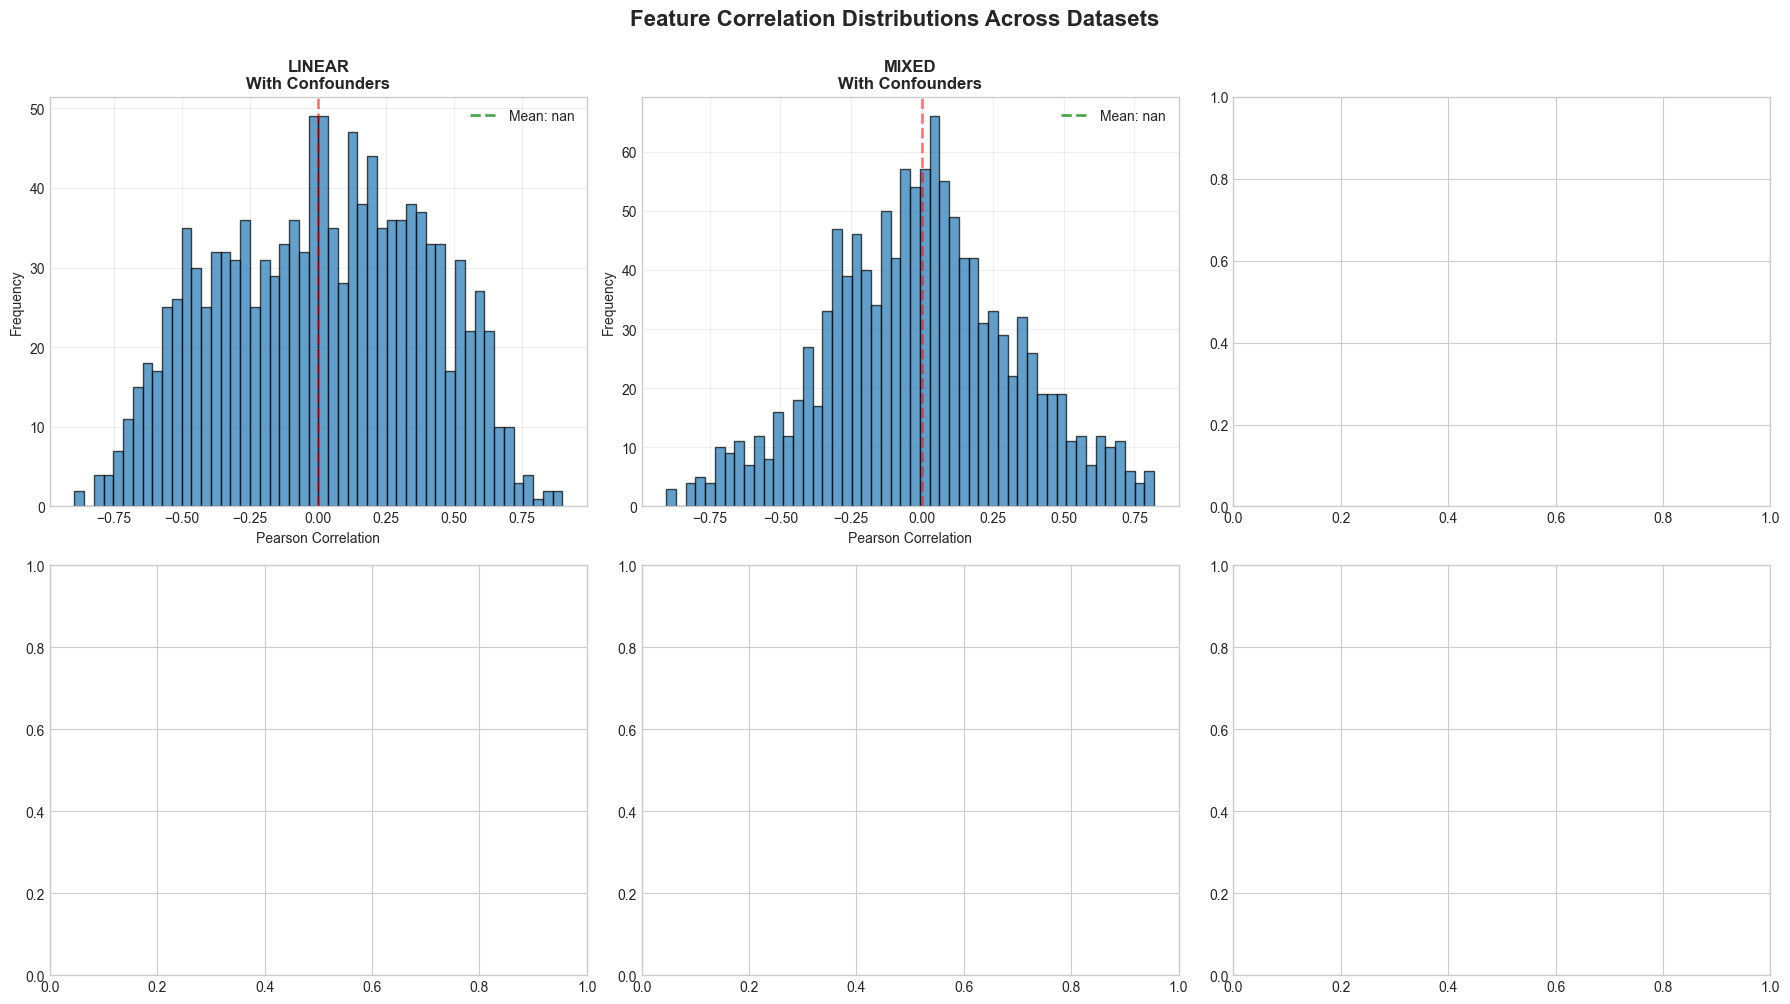


📈 KEY OBSERVATIONS:

LINEAR System:
  No Confounders:   Mean |corr| = nan, Max = nan
  With Confounders: Mean |corr| = nan, Max = nan
  → Ratio: nanx stronger with confounders


In [3]:
# Create correlation distribution plots for all datasets
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, dataset in enumerate(DATASETS):
    # Load data
    train_path = PROCESSED_DIR / f"{dataset}_train.parquet"
    data = pd.read_parquet(train_path)
    X = data.drop(columns=['Y'])
    
    # Calculate correlations
    corr = X.corr()
    upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    corr_values = upper_tri.stack().values
    
    # Plot histogram
    ax = axes[idx]
    ax.hist(corr_values, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=2)
    ax.axvline(corr_values.mean(), color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'Mean: {corr_values.mean():.3f}')
    
    system_type = dataset.split('_')[0]
    conf_type = 'With Confounders' if 'conf_f' in dataset else 'No Confounders'
    
    ax.set_title(f'{system_type.upper()}\n{conf_type}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Pearson Correlation')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Correlation Distributions Across Datasets', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Print comparison
print("\n📈 KEY OBSERVATIONS:")
print("=" * 80)
for i in range(0, len(DATASETS), 2):
    no_conf = stats_df.iloc[i]
    conf = stats_df.iloc[i+1]
    system = no_conf['dataset'].split('_')[0]
    print(f"\n{system.upper()} System:")
    print(f"  No Confounders:   Mean |corr| = {no_conf['mean_abs_corr']:.4f}, Max = {no_conf['max_abs_corr']:.4f}")
    print(f"  With Confounders: Mean |corr| = {conf['mean_abs_corr']:.4f}, Max = {conf['max_abs_corr']:.4f}")
    print(f"  → Ratio: {conf['mean_abs_corr'] / no_conf['mean_abs_corr']:.2f}x stronger with confounders")

---
## 2. Pairwise Feature Scatter Plots

Let's visualize relationships between adjacent features for each dataset.
We'll sample a subset of features to keep the visualization manageable.


📊 Creating pairplot for linear_conf_f50_s1000_p50...


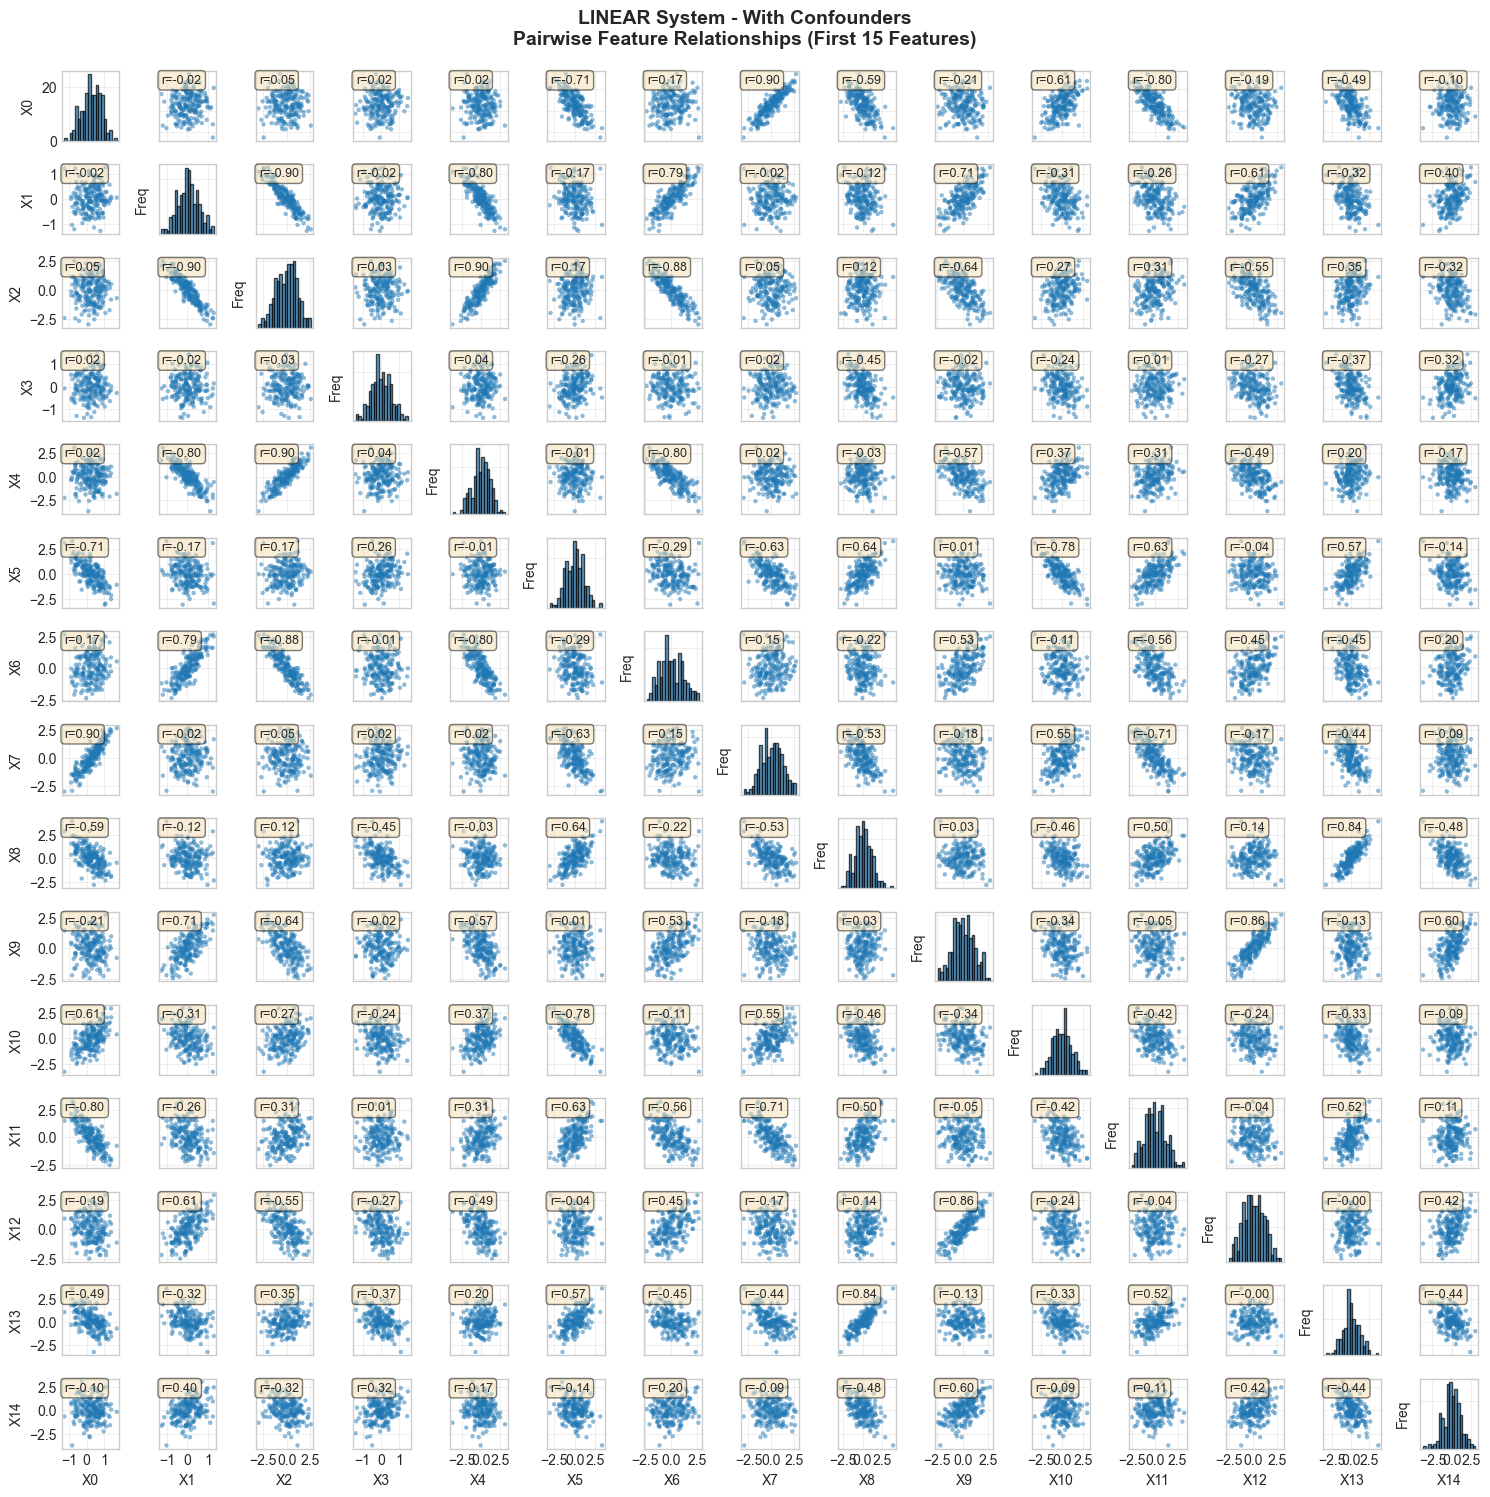


📊 Creating pairplot for mixed_no_conf_f50_s1000_p50...


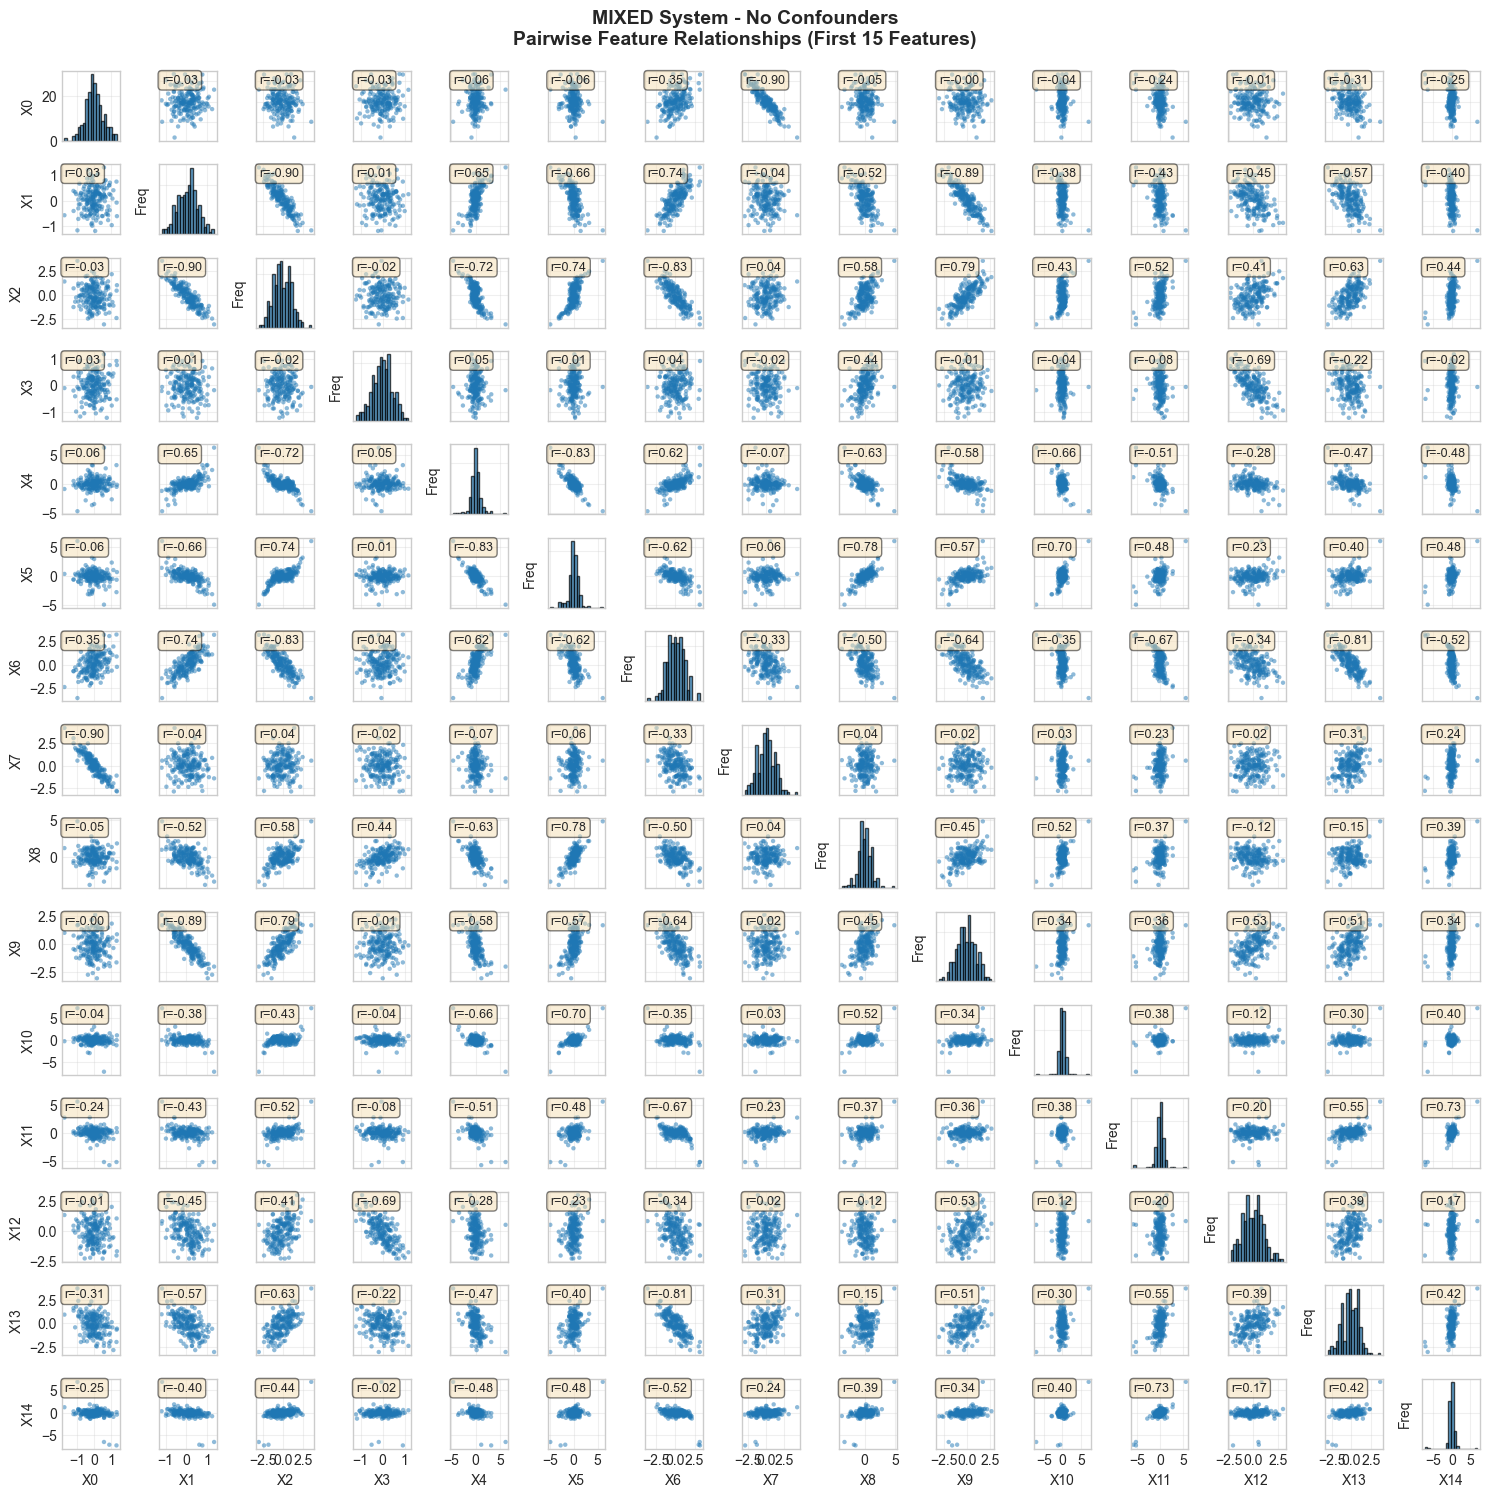

In [4]:
def plot_feature_pairs(dataset_name, n_features_to_show=6, sample_size=200):
    """
    Plot scatter plots for consecutive feature pairs.
    
    Parameters:
    -----------
    dataset_name : str
        Dataset name
    n_features_to_show : int
        Number of features to include in visualization
    sample_size : int
        Number of samples to plot
    """
    # Load data
    train_path = PROCESSED_DIR / f"{dataset_name}_train.parquet"
    data = pd.read_parquet(train_path)
    X = data.drop(columns=['Y'])
    
    # Sample data for plotting
    X_sample = X.sample(n=min(sample_size, len(X)), random_state=42)
    
    # Select features (first n_features_to_show)
    features = X.columns[:n_features_to_show].tolist()
    X_subset = X_sample[features]
    
    # Create pairplot-style grid
    n = len(features)
    fig, axes = plt.subplots(n, n, figsize=(15, 15))
    
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            
            if i == j:
                # Diagonal: histogram
                ax.hist(X_subset[features[i]], bins=20, alpha=0.7, edgecolor='black')
                ax.set_ylabel('Freq')
            else:
                # Off-diagonal: scatter plot
                ax.scatter(X_subset[features[j]], X_subset[features[i]], 
                          alpha=0.5, s=10, edgecolors='none')
                
                # Calculate and display correlation
                corr = X[features[j]].corr(X[features[i]])
                ax.text(0.05, 0.95, f'r={corr:.2f}', 
                       transform=ax.transAxes, 
                       fontsize=9, 
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            # Labels
            if i == n - 1:
                ax.set_xlabel(features[j], fontsize=10)
            else:
                ax.set_xticklabels([])
            
            if j == 0:
                ax.set_ylabel(features[i], fontsize=10)
            else:
                ax.set_yticklabels([])
            
            ax.grid(True, alpha=0.3)
    
    system_type = dataset_name.split('_')[0]
    conf_type = 'With Confounders' if '_no_conf_' not in dataset_name else 'No Confounders'
    plt.suptitle(f'{system_type.upper()} System - {conf_type}\nPairwise Feature Relationships (First {n_features_to_show} Features)', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    return fig

# Create plots for all datasets
for dataset in DATASETS:
    print(f"\n📊 Creating pairplot for {dataset}...")
    fig = plot_feature_pairs(dataset, n_features_to_show=15, sample_size=200)
    plt.show()
    plt.close(fig)

---
## 3. Comparative Analysis: Mixed Systems

Deep dive into the mixed systems to understand the dramatic difference.

In [5]:
# Load both mixed datasets
mixed_no_conf = pd.read_parquet(PROCESSED_DIR / 'mixed_no_conf_f50_s1000_p50_train.parquet')
mixed_conf = pd.read_parquet(PROCESSED_DIR / 'mixed_conf_f50_s1000_p50_train.parquet')

X_no_conf = mixed_no_conf.drop(columns=['Y'])
X_conf = mixed_conf.drop(columns=['Y'])

# Calculate correlations
corr_no_conf = X_no_conf.corr()
corr_conf = X_conf.corr()

print("\n🔬 DETAILED COMPARISON: MIXED SYSTEMS")
print("=" * 80)

# Get correlation values (upper triangle)
upper_tri_no_conf = corr_no_conf.where(np.triu(np.ones(corr_no_conf.shape), k=1).astype(bool))
upper_tri_conf = corr_conf.where(np.triu(np.ones(corr_conf.shape), k=1).astype(bool))

corr_vals_no_conf = upper_tri_no_conf.stack().values
corr_vals_conf = upper_tri_conf.stack().values

print(f"\nNo Confounders:")
print(f"  Mean |correlation|: {np.abs(corr_vals_no_conf).mean():.4f}")
print(f"  Median |correlation|: {np.median(np.abs(corr_vals_no_conf)):.4f}")
print(f"  Max |correlation|: {np.abs(corr_vals_no_conf).max():.4f}")
print(f"  % with |corr| > 0.1: {(np.abs(corr_vals_no_conf) > 0.1).sum() / len(corr_vals_no_conf) * 100:.1f}%")
print(f"  % with |corr| > 0.3: {(np.abs(corr_vals_no_conf) > 0.3).sum() / len(corr_vals_no_conf) * 100:.1f}%")

print(f"\nWith Confounders:")
print(f"  Mean |correlation|: {np.abs(corr_vals_conf).mean():.4f}")
print(f"  Median |correlation|: {np.median(np.abs(corr_vals_conf)):.4f}")
print(f"  Max |correlation|: {np.abs(corr_vals_conf).max():.4f}")
print(f"  % with |corr| > 0.1: {(np.abs(corr_vals_conf) > 0.1).sum() / len(corr_vals_conf) * 100:.1f}%")
print(f"  % with |corr| > 0.3: {(np.abs(corr_vals_conf) > 0.3).sum() / len(corr_vals_conf) * 100:.1f}%")

print(f"\n⚠️  Ratio (with/without confounders): {np.abs(corr_vals_conf).mean() / np.abs(corr_vals_no_conf).mean():.2f}x")


🔬 DETAILED COMPARISON: MIXED SYSTEMS

No Confounders:
  Mean |correlation|: nan
  Median |correlation|: nan
  Max |correlation|: nan
  % with |corr| > 0.1: 36.2%
  % with |corr| > 0.3: 17.4%

With Confounders:
  Mean |correlation|: nan
  Median |correlation|: nan
  Max |correlation|: nan
  % with |corr| > 0.1: 33.9%
  % with |corr| > 0.3: 11.6%

⚠️  Ratio (with/without confounders): nanx


### Side-by-Side Correlation Heatmaps

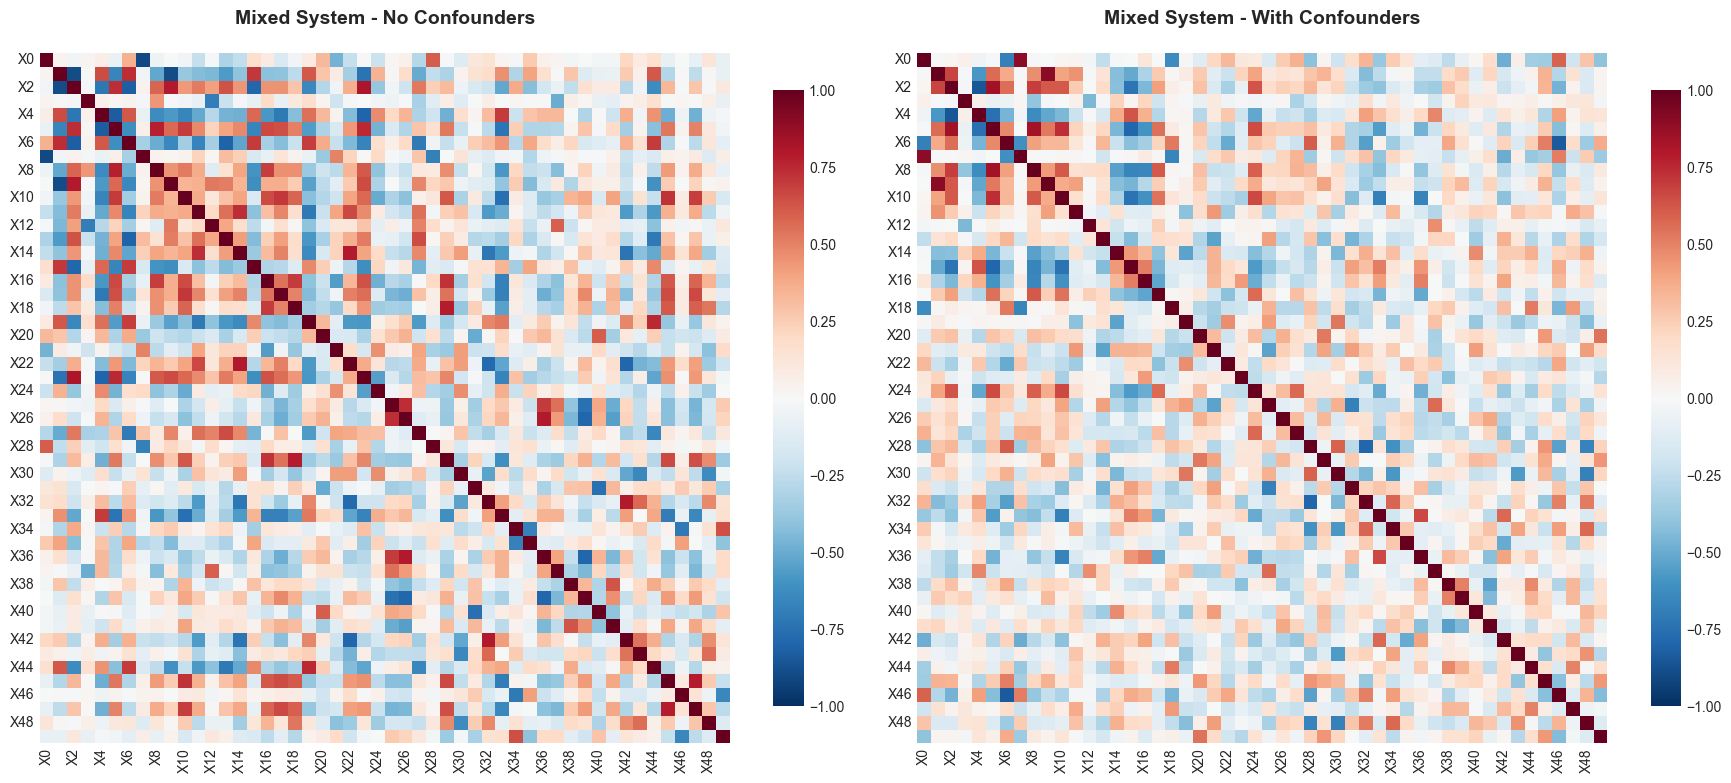

In [6]:
# Create side-by-side heatmaps for first 20 features
n_features_show = 50

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# No confounders
sns.heatmap(corr_no_conf.iloc[:n_features_show, :n_features_show], 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Mixed System - No Confounders\n', fontsize=14, fontweight='bold')

# With confounders
sns.heatmap(corr_conf.iloc[:n_features_show, :n_features_show], 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Mixed System - With Confounders\n', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Distribution of Feature Values

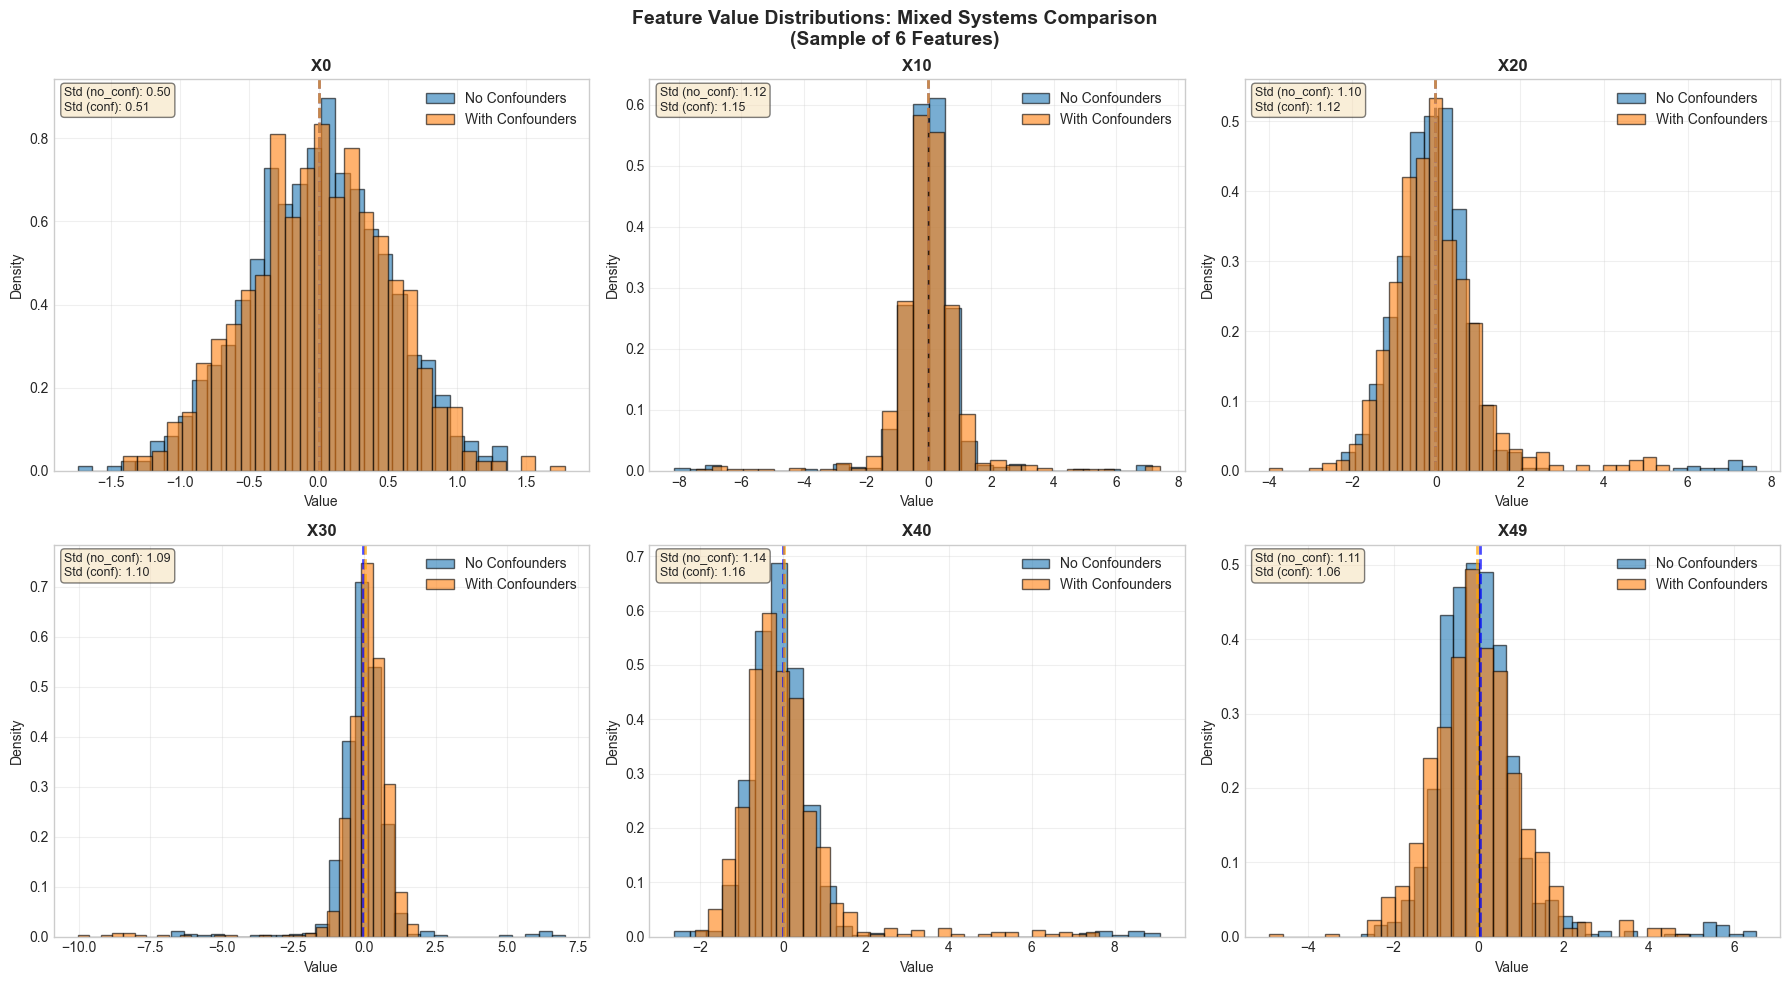

In [7]:
# Compare feature value distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Sample 6 features to compare
features_to_plot = [f'X{i}' for i in [0, 10, 20, 30, 40, 49]]

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    # Plot both distributions
    ax.hist(X_no_conf[feature], bins=30, alpha=0.6, label='No Confounders', 
            edgecolor='black', density=True)
    ax.hist(X_conf[feature], bins=30, alpha=0.6, label='With Confounders', 
            edgecolor='black', density=True)
    
    # Add statistics
    ax.axvline(X_no_conf[feature].mean(), color='blue', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(X_conf[feature].mean(), color='orange', linestyle='--', linewidth=2, alpha=0.7)
    
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add std annotation
    ax.text(0.02, 0.98, 
            f'Std (no_conf): {X_no_conf[feature].std():.2f}\nStd (conf): {X_conf[feature].std():.2f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Feature Value Distributions: Mixed Systems Comparison\n(Sample of 6 Features)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3b. Comparative Analysis: Linear Systems

Deep dive into the linear systems to compare no-confounder vs confounder behavior.


In [8]:
# Load both linear datasets
linear_no_conf = pd.read_parquet(PROCESSED_DIR / 'linear_no_conf_f50_s1000_p50_train.parquet')
linear_conf = pd.read_parquet(PROCESSED_DIR / 'linear_conf_f50_s1000_p50_train.parquet')

X_linear_no_conf = linear_no_conf.drop(columns=['Y'])
X_linear_conf = linear_conf.drop(columns=['Y'])

# Calculate correlations
corr_linear_no_conf = X_linear_no_conf.corr()
corr_linear_conf = X_linear_conf.corr()

print("\n🔬 DETAILED COMPARISON: LINEAR SYSTEMS")
print("=" * 80)

# Get correlation values (upper triangle)
upper_tri_linear_no_conf = corr_linear_no_conf.where(
    np.triu(np.ones(corr_linear_no_conf.shape), k=1).astype(bool))
upper_tri_linear_conf = corr_linear_conf.where(
    np.triu(np.ones(corr_linear_conf.shape), k=1).astype(bool))

corr_vals_linear_no_conf = upper_tri_linear_no_conf.stack().values
corr_vals_linear_conf = upper_tri_linear_conf.stack().values

print(f"\nNo Confounders:")
print(f"  Mean |correlation|: {np.abs(corr_vals_linear_no_conf).mean():.4f}")
print(f"  Median |correlation|: {np.median(np.abs(corr_vals_linear_no_conf)):.4f}")
print(f"  Max |correlation|: {np.abs(corr_vals_linear_no_conf).max():.4f}")
print(f"  % with |corr| > 0.1: {(np.abs(corr_vals_linear_no_conf) > 0.1).sum() / len(corr_vals_linear_no_conf) * 100:.1f}%")
print(f"  % with |corr| > 0.3: {(np.abs(corr_vals_linear_no_conf) > 0.3).sum() / len(corr_vals_linear_no_conf) * 100:.1f}%")

print(f"\nWith Confounders:")
print(f"  Mean |correlation|: {np.abs(corr_vals_linear_conf).mean():.4f}")
print(f"  Median |correlation|: {np.median(np.abs(corr_vals_linear_conf)):.4f}")
print(f"  Max |correlation|: {np.abs(corr_vals_linear_conf).max():.4f}")
print(f"  % with |corr| > 0.1: {(np.abs(corr_vals_linear_conf) > 0.1).sum() / len(corr_vals_linear_conf) * 100:.1f}%")
print(f"  % with |corr| > 0.3: {(np.abs(corr_vals_linear_conf) > 0.3).sum() / len(corr_vals_linear_conf) * 100:.1f}%")

print(f"\n⚠️  Ratio (with/without confounders): {np.abs(corr_vals_linear_conf).mean() / np.abs(corr_vals_linear_no_conf).mean():.2f}x")



🔬 DETAILED COMPARISON: LINEAR SYSTEMS

No Confounders:
  Mean |correlation|: nan
  Median |correlation|: nan
  Max |correlation|: nan
  % with |corr| > 0.1: 40.7%
  % with |corr| > 0.3: 26.2%

With Confounders:
  Mean |correlation|: nan
  Median |correlation|: nan
  Max |correlation|: nan
  % with |corr| > 0.1: 40.3%
  % with |corr| > 0.3: 24.8%

⚠️  Ratio (with/without confounders): nanx


### Side-by-Side Correlation Heatmaps


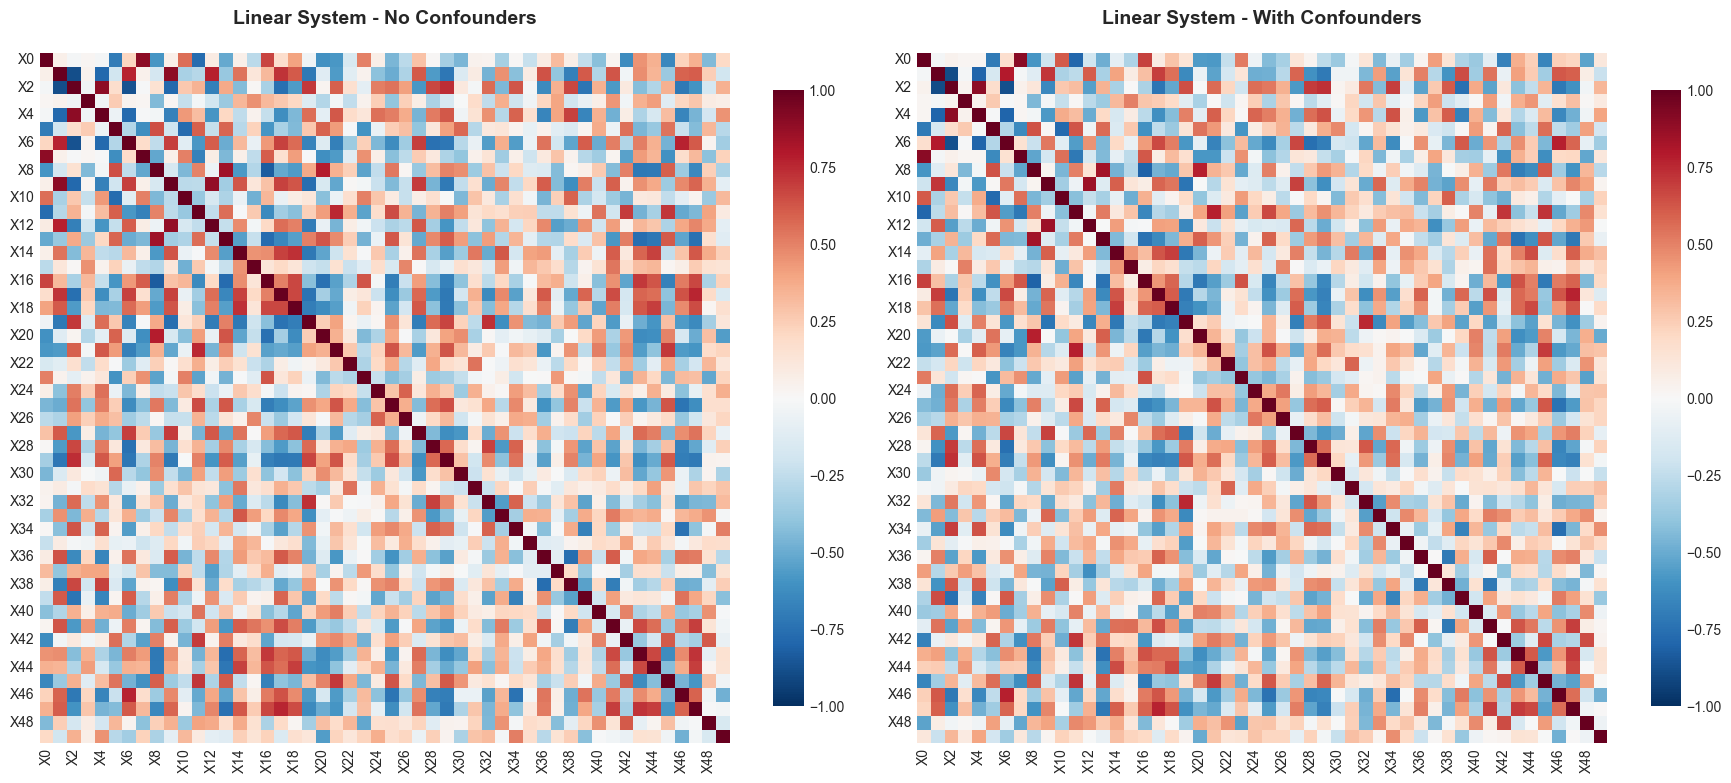

In [9]:
# Create side-by-side heatmaps for linear systems
n_features_show = 50

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# No confounders
sns.heatmap(corr_linear_no_conf.iloc[:n_features_show, :n_features_show],
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Linear System - No Confounders\n', fontsize=14, fontweight='bold')

# With confounders
sns.heatmap(corr_linear_conf.iloc[:n_features_show, :n_features_show],
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Linear System - With Confounders\n', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


---
## 5. Summary and Recommendations

Based on the analysis above, summarize key findings.

In [10]:
print("\n" + "="*80)
print("📋 SUMMARY OF FINDINGS")
print("="*80)

print("\n1. CORRELATION STRENGTH ACROSS DATASETS:")
print("   " + "-"*70)
for i in range(0, len(DATASETS), 2):
    no_conf_stats = stats_df.iloc[i]
    conf_stats = stats_df.iloc[i+1]
    system = no_conf_stats['dataset'].split('_')[0]
    ratio = conf_stats['mean_abs_corr'] / no_conf_stats['mean_abs_corr']
    print(f"   {system.upper():12s}: {no_conf_stats['mean_abs_corr']:.4f} → {conf_stats['mean_abs_corr']:.4f} ({ratio:.1f}x with confounders)")

print("\n2. EDGE DETECTABILITY (TRUE EDGES):")
print("   " + "-"*70)
print(f"   Mixed no_conf: Mean |corr| = {np.mean(edge_corrs_no_conf):.4f} (TOO WEAK!)")
print(f"   Mixed conf:    Mean |corr| = {np.mean(edge_corrs_conf):.4f} (DETECTABLE)")

print("\n3. ROOT CAUSE:")
print("   " + "-"*70)
print("   • Per-edge normalization in generate_mixed_system() destroys causal signal")
print("   • Without confounders: signal starts weak and gets normalized away")
print("   • With confounders: strong baseline correlations persist despite normalization")

print("\n4. RECOMMENDATIONS:")
print("   " + "-"*70)
print("   Option A: Reduce normalization frequency (only when std > threshold)")
print("   Option B: Use gentler normalization (clip instead of standardize)")
print("   Option C: Reduce noise level for mixed systems")
print("   Option D: Accept the current behavior as realistic (very noisy systems)")

print("\n" + "="*80 + "\n")


📋 SUMMARY OF FINDINGS

1. CORRELATION STRENGTH ACROSS DATASETS:
   ----------------------------------------------------------------------
   LINEAR      : nan → nan (nanx with confounders)

2. EDGE DETECTABILITY (TRUE EDGES):
   ----------------------------------------------------------------------


NameError: name 'edge_corrs_no_conf' is not defined